In [17]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [18]:
import torch
from matplotlib import pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
import pickle

with open(f"activations_save/activations_vit_cifar100_rank.pkl", "rb") as f:
    activations = pickle.load(f)

In [20]:
import math
import numpy as np

def cache_all_layer_singular_values(layer_name, io_key="input", sample_idx=0):
    sv_dict = {}
    for layer in activations:
        if layer_name not in layer:
            continue
        layer_id = int(layer.split(".")[0].split("_")[1])
        x = activations[layer][io_key][sample_idx]
        X = x.reshape(-1, x.shape[-1]).to(torch.float32).to(device)
        sv = torch.linalg.svdvals(X).cpu()
        sv_dict[layer_id] = sv
    return sv_dict

def analyze_energy_ratio_from_sv_cache(sv_cache, rank_ratio):
    layer_ids, ratios, ks, totals = [], [], [], []
    for layer_id in sorted(sv_cache.keys()):
        sv = sv_cache[layer_id]
        k = max(1, int(math.ceil(len(sv) * rank_ratio)))
        energy = sv.pow(2)
        # energy = sv
        total = energy.sum()
        topk = energy[:k].sum()
        ratio = (topk / (total + 1e-12)).item()
        layer_ids.append(layer_id)
        ratios.append(ratio)
        ks.append(k)
        totals.append(total.item())
    return layer_ids, ratios, ks, totals

def plot_energy_ratios(layer_ids, ratios, layer_name, rank_ratio):
    plt.figure(figsize=(8, 4))
    plt.plot(layer_ids, ratios, marker="o")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: rank_ratio={rank_ratio} energy capture")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
def plot_multi_rank_energy_ratios(sv_cache, layer_name, rank_ratios, legend_loc="best"):
    import seaborn as sns
    sns.set_theme(style="whitegrid", font="Times New Roman", font_scale=1.3)
    plt.figure(figsize=(8, 5))
    for rr in rank_ratios:
        layer_ids, ratios, ks, totals = analyze_energy_ratio_from_sv_cache(sv_cache, rr)
        plt.plot(layer_ids, ratios, marker="o", label=f"rank_ratio={rr:.4f}")
    plt.xlabel("Layer id")
    plt.ylabel("Energy captured (sum sigma^2)")
    plt.title(f"{layer_name}: Energy ratio for different rank_ratio")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.show()
    

In [21]:
# 只需SVD一次，缓存所有层的奇异值
mlp_layer_name = "mlp_gate_proj"  # 例如："mlp_gate_proj"、"self_attn_o_proj"等
mlp_sv_cache = cache_all_layer_singular_values(mlp_layer_name, io_key="input", sample_idx=0)

# 只需SVD一次，缓存所有层的奇异值
attn_layer_name = "self_attn_q_proj"  # 例如："mlp_gate_proj"、"self_attn_q_proj"等
attn_sv_cache = cache_all_layer_singular_values(attn_layer_name, io_key="input", sample_idx=0)

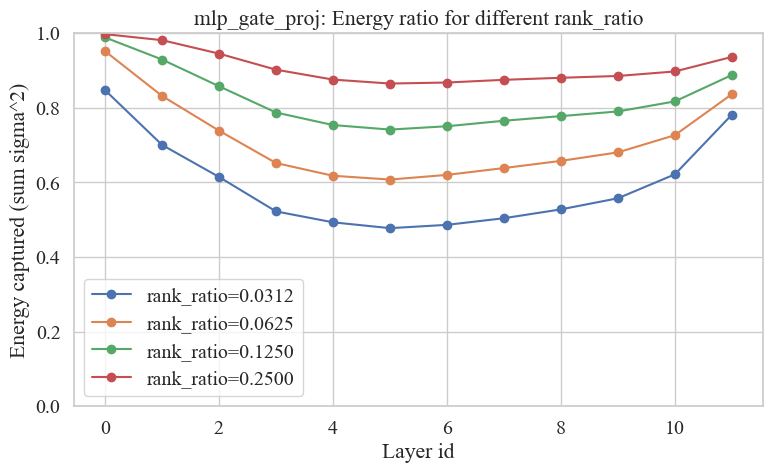

In [22]:
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(mlp_sv_cache, "mlp_gate_proj", rank_ratios)

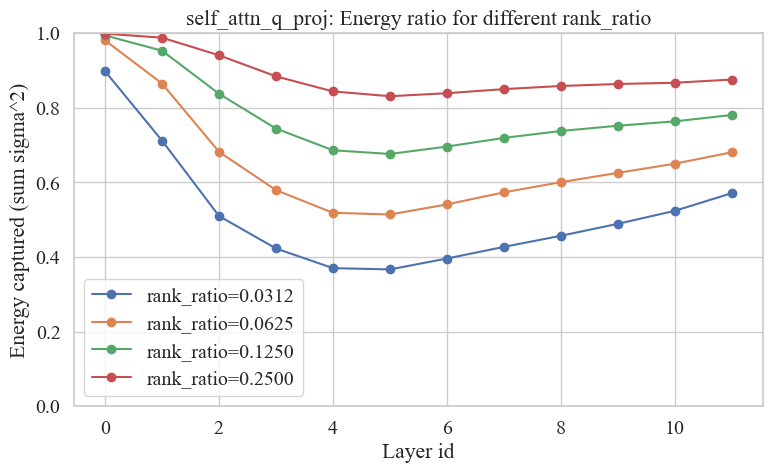

In [23]:
rank_ratios = [1/32, 1/16, 1/8, 1/4]
plot_multi_rank_energy_ratios(attn_sv_cache, "self_attn_q_proj", rank_ratios)